# Membership Sustainability Threshold — what should a new operator target?

**The questions from the meeting**
1. **What total revenue number should a new operator target?**
2. **Within that number, what % should come from membership?**
3. **Fallback:** if membership stays low, how many *retail (client) washes* make the business sustainable anyway?

Target one-line rule: *"A site is sustainable if it does >= \$X/month with >= Y% membership — OR, with low membership, if it runs >= Z retail washes/month."*

**Unit = a single site** (a new operator opens a site; an operator total = sites x per-site target). **Operator = `client_id`**. **Data:** `monthly_kpi-aggregated.csv`, Jan-2024 -> Mar-2026 (27 months).

**Grain & source columns** · each row = site x month x **package**. We dedup to **site-month** and use the team's pre-built site-level columns: `membership_sales_total` (membership summed across packages) and `membership_pct_sales_total` (authoritative membership % of sales). `retail_sales_amount` / `retail_wash_count` are already site-level.

**Limitations (kept honest)** · no customer IDs, so the fallback is measured in **retail wash volume** (`retail_wash_count`), not unique returning customers (washes ≠ people). No cost/profit cols -> "sustainable" = predictable + non-declining revenue, not measured profit. Thresholds are **associational** over a 27-month window (2026 partial).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

RAW = pd.read_csv('../data/monthly_kpi-aggregated.csv', encoding='latin-1')
RAW = RAW.drop(columns=[c for c in RAW.columns if str(c).startswith('Unnamed')])
print('rows:', len(RAW), '| sites:', RAW.groupby(['client_id','site_id']).ngroups,
      '| operators:', RAW.client_id.nunique(), '| states:', RAW.state.nunique())
RAW[['client_id','site_id','year','month','membership_sales_total','membership_pct_sales_total','retail_sales_amount']].head(3)

rows: 287941 | sites: 1679 | operators: 616 | states: 49


,client_id,site_id,year,month,membership_sales_total,membership_pct_sales_total,retail_sales_amount
0,360 Car Wash,1,2024,3,"8,795.34",14.38,"52,359.69"
1,360 Car Wash,1,2024,3,"8,795.34",14.38,"52,359.69"
2,360 Car Wash,1,2024,3,"8,795.34",14.38,"52,359.69"


## Step 1-2 · Dedup to site-month & operator-month, compute key metrics

In [2]:
# site-month: site-level cols are constant across package rows -> take first
site = RAW.groupby(['client_id','site_id','year','month']).agg(
    membership_sales=('membership_sales_total','first'),
    membership_pct=('membership_pct_sales_total','first'),
    membership_purchased_count=('membership_purchased_count','sum'),   # count IS per-package
    retail_sales=('retail_sales_amount','first'),
    retail_volume=('retail_wash_count','first'),                       # retail client washes (fallback metric)
    region=('region','first'), state=('state','first'),
).reset_index()
site['total_revenue']    = site.membership_sales + site.retail_sales
site['avg_member_value'] = site.membership_sales / site.membership_purchased_count.replace(0, np.nan)
site['date'] = pd.to_datetime(dict(year=site.year, month=site.month, day=1))
site = site.sort_values(['client_id','site_id','date']).reset_index(drop=True)

# operator-month roll-up
op = site.groupby(['client_id','year','month']).agg(
    membership_sales=('membership_sales','sum'), retail_sales=('retail_sales','sum'),
    total_revenue=('total_revenue','sum'), n_sites=('site_id','nunique'),
    region=('region','first'), state=('state','first')).reset_index()
op['membership_pct'] = 100 * op.membership_sales / op.total_revenue
op['date'] = pd.to_datetime(dict(year=op.year, month=op.month, day=1))
print('site-months:', len(site), '| sites:', site.groupby(["client_id","site_id"]).ngroups)
site.head(3)

site-months: 25585 | sites: 1679


,client_id,site_id,year,month,membership_sales,membership_pct,membership_purchased_count,retail_sales,retail_volume,region,state,total_revenue,avg_member_value,date
0,360 Car Wash,1,2024,3,"8,795.34",14.38,866,"52,359.69",4611,South,TX,"61,155.03",10.16,2024-03-01
1,360 Car Wash,1,2024,4,"29,961.10",36.26,1366,"52,656.54",4502,South,TX,"82,617.64",21.93,2024-04-01
2,360 Car Wash,1,2024,5,"42,705.67",47.15,1601,"47,873.82",3795,South,TX,"90,579.49",26.67,2024-05-01


## Step 3 · Membership % over time — by STATE and within multi-state operators

Two views in one figure:
- **(top)** revenue-weighted membership % for the **top-8 states** by site count — regional penetration.
- **(bottom)** the same metric for the **3 largest multi-state operators**, split by state — does one brand behave the same everywhere?

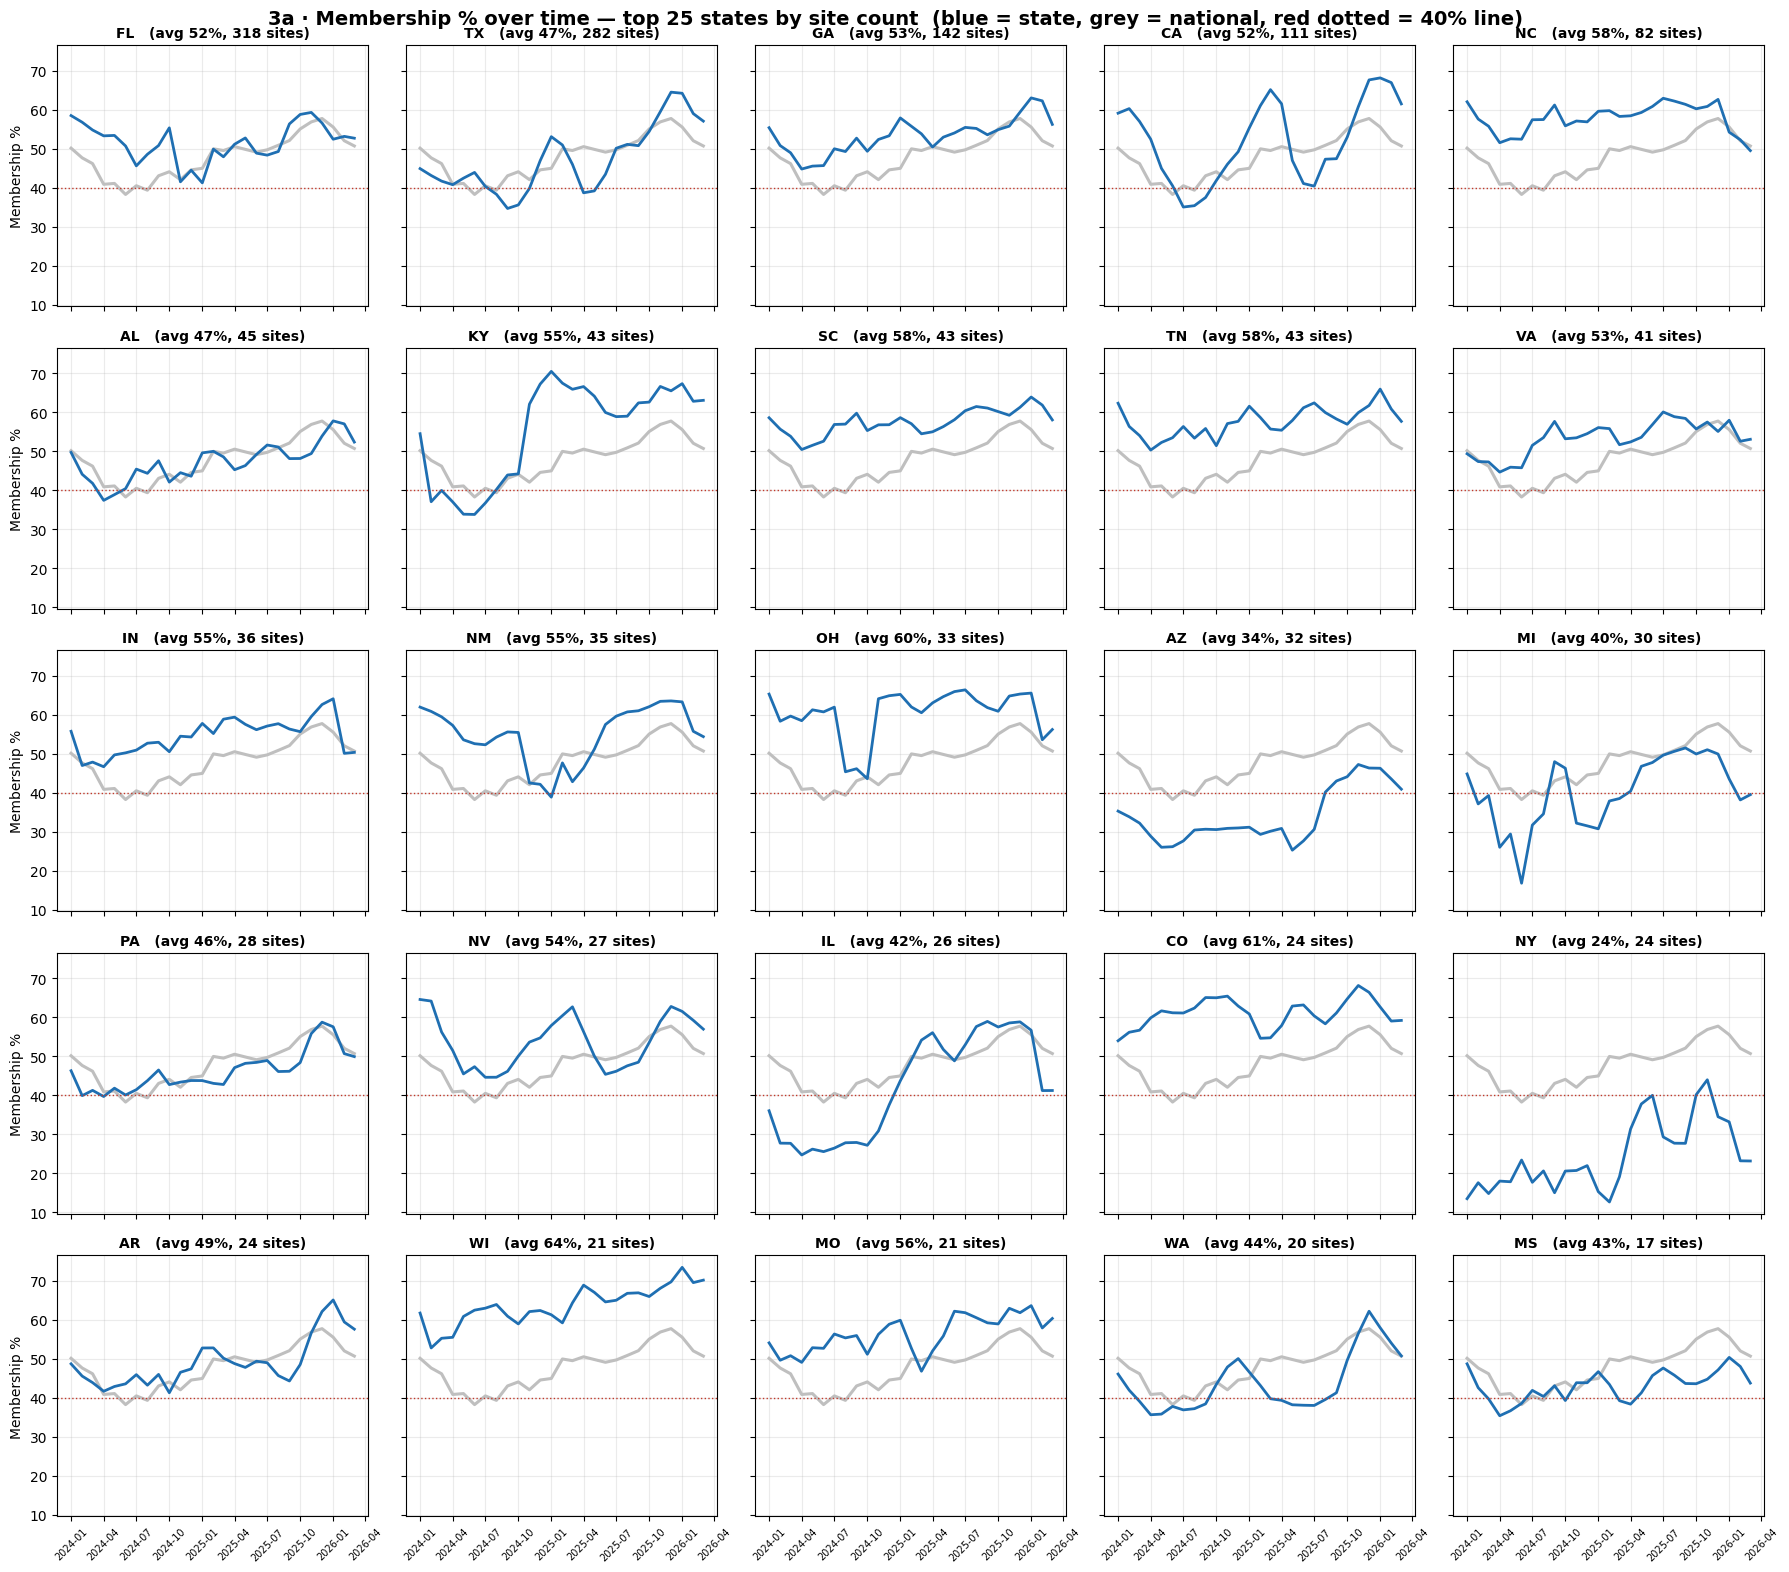

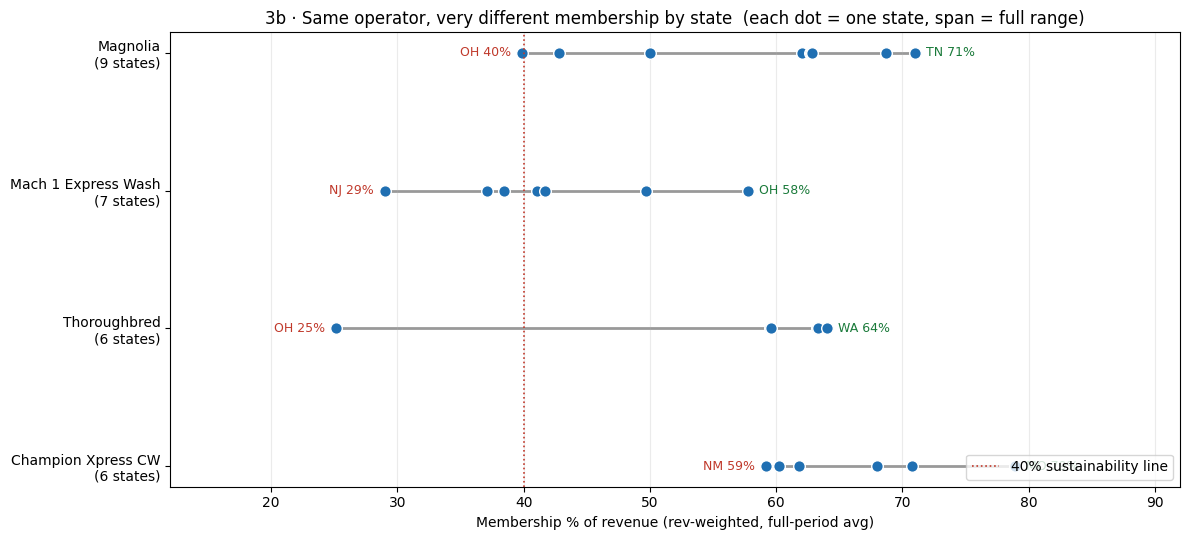

State membership % (rev-weighted), top-8 states:
state
WI   64.10
CO   60.90
SC   57.40
NV   57.20
TN   57.10
NC   56.60
MO   56.40
KY   54.40
AR   54.40
CA   53.50
VA   53.30
GA   53.30
NM   52.80
OH   52.60
IN   51.40
TX   51.00
FL   49.70
AL   47.90
PA   47.30
WA   45.00
MS   42.80
IL   41.20
AZ   36.60
MI   27.00
NY   15.50


In [3]:
def wpct(d):  # revenue-weighted membership %
    return 100 * d.membership_sales.sum() / d.total_revenue.sum()

site_cnt = site.groupby('state').apply(lambda d: d.groupby(['client_id','site_id']).ngroups, include_groups=False)
top_states = site_cnt.sort_values(ascending=False).head(25).index.tolist()

# ===== 3a: small multiples — one clean panel per state, TOP 25 (3-month smoothed) =====
nat = site.groupby('date').apply(wpct, include_groups=False).rolling(3, min_periods=1).mean()
fig, axes = plt.subplots(5, 5, figsize=(18, 16), sharex=True, sharey=True)
for ax, s in zip(axes.flat, top_states):
    ts = site[site.state==s].groupby('date').apply(wpct, include_groups=False).rolling(3, min_periods=1).mean()
    ax.plot(nat.index, nat.values, color='0.75', lw=2.2, label='National')
    ax.plot(ts.index, ts.values, color='#1f6fb2', lw=2.0, label=s)
    ax.axhline(40, color='#c0392b', ls=':', lw=1)                 # 40% sustainability line
    ax.set_title(f'{s}   (avg {ts.mean():.0f}%, {site_cnt[s]} sites)', fontsize=10, weight='bold')
    ax.grid(alpha=.25); ax.tick_params(axis='x', rotation=45, labelsize=7)
for r in range(5):
    axes[r,0].set_ylabel('Membership %')
fig.suptitle('3a · Membership % over time — top 25 states by site count  '
             '(blue = state, grey = national, red dotted = 40% line)', fontsize=14, weight='bold')
plt.tight_layout(); plt.show()

# ===== 3b: dumbbell — membership % spread ACROSS states within each big operator =====
op_nstate = RAW.groupby('client_id').state.nunique().sort_values(ascending=False)
multi_ops = op_nstate.head(4).index.tolist()
fig, ax = plt.subplots(figsize=(12, 5.5))
for i, o in enumerate(multi_ops):
    bs = site[site.client_id==o].groupby('state').apply(wpct, include_groups=False).sort_values()
    ax.plot([bs.min(), bs.max()], [i, i], color='0.6', lw=2, zorder=1)
    ax.scatter(bs.values, [i]*len(bs), s=70, color='#1f6fb2', zorder=2, edgecolor='w')
    ax.annotate(f'{bs.index[0]} {bs.iloc[0]:.0f}%', (bs.min(), i), xytext=(-8,0),
                textcoords='offset points', ha='right', va='center', fontsize=9, color='#c0392b')
    ax.annotate(f'{bs.index[-1]} {bs.iloc[-1]:.0f}%', (bs.max(), i), xytext=(8,0),
                textcoords='offset points', ha='left', va='center', fontsize=9, color='#1a7a3a')
ax.axvline(40, color='#c0392b', ls=':', lw=1.2, label='40% sustainability line')
ax.set_yticks(range(len(multi_ops)))
ax.set_yticklabels([f'{o}\n({op_nstate[o]} states)' for o in multi_ops])
ax.set(title='3b · Same operator, very different membership by state  (each dot = one state, span = full range)',
       xlabel='Membership % of revenue (rev-weighted, full-period avg)')
ax.legend(loc='lower right'); ax.grid(alpha=.25, axis='x'); ax.invert_yaxis()
ax.set_xlim(12, 92)   # padding so the edge state labels are not clipped
plt.tight_layout(); plt.show()

print('State membership % (rev-weighted), top-8 states:')
print(site[site.state.isin(top_states)].groupby('state').apply(wpct, include_groups=False).round(1).sort_values(ascending=False).to_string())

### 📊 How to read these two charts

**3a (small multiples, top-25 states):** each panel is one state's membership % over time (blue), with the **national line in grey** and the **40% sustainability line dotted red**; the title shows the state's avg % and site count. Panels are ordered by site count, so the **top rows are the high-volume, reliable markets** and the **bottom rows are thinner, noisier states**. Compare blue-vs-grey per panel.
**3b (dumbbell):** each row is one multi-state operator; every dot is one state's average membership %, and the bar is its full range. Red label = weakest state, green = strongest.

**Story — geography moves membership more than execution does**
- **High-volume states (top rows) sit in a tight ~47–58% band**, mostly **tracking the national line and staying above the 40% red line** — established markets are already in "sustainable mix" territory. Early-2024 wobble is just smaller denominators before sites ramped.
- **Thinner states (lower rows) are noisier and a few dip below the 40% line** — those are the genuinely under-penetrated markets (and small-sample, so read them with caution).
- **But within a single operator, membership nearly doubles by state** (3b): Magnolia ~40% (OH) → ~71% (TN); Mach 1 ~29% (NJ) → ~58% (OH). Same brand, same playbook — the market sets the ceiling.
- **Insight:** membership mix is **not purely an execution lever**; local market (climate, commuter base, competition, price tolerance) drives a big share of it. A new operator should benchmark its membership target **against its state**, not a national average — and an operator with a state below the red line (e.g. Mach 1 in NJ) has a clear fix-it target.

## Step 4 · Define "sustainable", then read the thresholds off the data

No cost/profit columns, so **sustainable = predictable + not shrinking** — but defined carefully so it doesn't punish healthy growth or trip on one bad quarter. Stability is measured on **quarterly, seasonally-adjusted** revenue:
- aggregate each site to quarterly revenue, then **deseasonalize** by dividing out the national quarter-of-year index (winter↔summer swings don't read as "instability");
- **predictable** — **detrended volatility**: the scatter of revenue *around its own fitted trend* (residual `CV`) is at or below the median site. This rewards *smoothness*, so a steadily-growing site counts as predictable rather than being flagged for its high raw CV;
- **not shrinking** — **net change** from the first two quarters to the last two ≥ **−5%** (a tolerant direction test, so a single down/endpoint quarter doesn't sink a healthy site).

Revenue and retail-wash levels stay in **monthly** units for interpretability. For each lever we plot **P(sustainable)** vs that lever and read where it beats the base rate — that level is the target.

In [4]:
# ---- stability on QUARTERLY, DESEASONALIZED revenue ----
site['q'] = site.date.dt.to_period('Q')
q = site.groupby(['client_id','site_id','q'])['total_revenue'].sum().reset_index()
q['qoy'] = q['q'].dt.quarter
q['site_mean'] = q.groupby(['client_id','site_id']).total_revenue.transform('mean')
seasonal = (q.total_revenue / q.site_mean).groupby(q.qoy).mean()   # national multiplicative index
q['adj'] = q.total_revenue / q['qoy'].map(seasonal)
q = q.sort_values(['client_id','site_id','q'])

def stats(d):
    y = d.adj.values; n = len(y)
    if n < 2 or y.mean() == 0:
        return pd.Series({'quarters': n, 'detrend_cv': np.nan, 'net_growth': np.nan})
    b1, b0 = np.polyfit(np.arange(n), y, 1)
    resid = y - (b1*np.arange(n) + b0)
    return pd.Series({'quarters': n,
                      'detrend_cv': resid.std()/y.mean(),               # smoothness around the trend
                      'net_growth': y[-2:].mean()/y[:2].mean() - 1})    # first 2 vs last 2 quarters
stab = q.groupby(['client_id','site_id']).apply(stats, include_groups=False).reset_index()

# ---- monthly-scale features (keep $/washes in monthly units) ----
feat = site.groupby(['client_id','site_id']).agg(
    avg_rev=('total_revenue','mean'), avg_member_pct=('membership_pct','mean'),
    avg_retail_vol=('retail_volume','mean')).reset_index()

S = stab.merge(feat, on=['client_id','site_id'])
S = S[S.quarters >= 6].dropna(subset=['detrend_cv','net_growth']).copy()
S['sustainable'] = ((S.detrend_cv <= S.detrend_cv.median()) & (S.net_growth >= -0.05)).astype(int)
base = S.sustainable.mean()
print('Seasonal index (1=avg):', {f'Q{k}': round(v,2) for k,v in seasonal.items()},
      f'-> swing {seasonal.max()/seasonal.min():.2f}x (mild)')
print(f'eligible sites (>=6 quarters): {len(S)} | base sustainable rate: {base:.0%}')

Seasonal index (1=avg): {'Q1': 1.07, 'Q2': 1.01, 'Q3': 0.94, 'Q4': 0.94} -> swing 1.14x (mild)
eligible sites (>=6 quarters): 755 | base sustainable rate: 38%


### Where the 38% comes from

Each site must pass **both** gates: **smooth** (detrended volatility ≤ median, left of the dashed vertical) **and** **not shrinking** (net change ≥ −5%, above the dashed horizontal). The green points in the upper-left region are the ~38% that pass both. Crucially, a fast-but-smooth grower now sits **left** (low residual scatter) instead of being exiled right by raw CV.

*Robustness:* the granularity choice barely matters — **monthly** (base 34%), **raw quarterly** (32%), **deseasonalized** (33%) and this **detrended + tolerant** rule (38%) assign the **same label to ≥92% of sites**, and the membership-tier ranking is identical every time. The detrended/tolerant version mainly rescues ~35 *fast-but-smooth growers* that raw CV wrongly flagged. Seasonality is mild (~1.14× swing), so the adjustments are rigor safeguards more than result-changers.

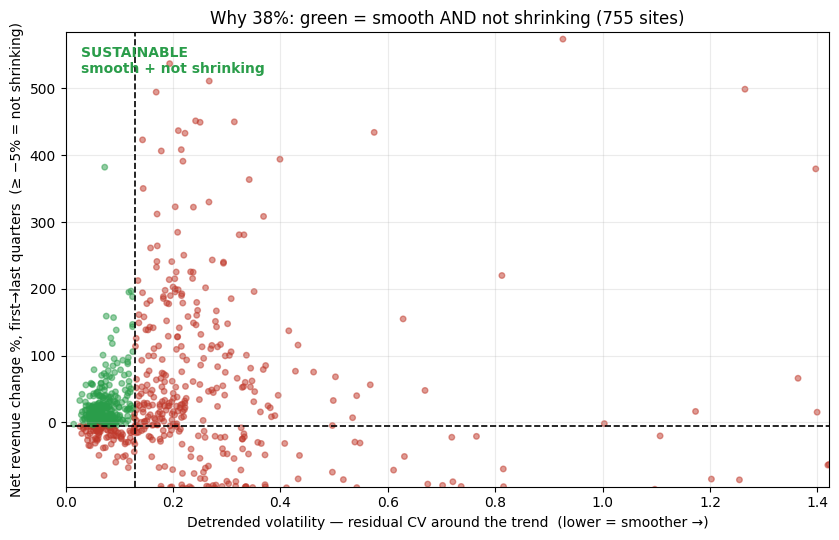

pass smoothness (detrend CV<=median): 50%  |  pass not-shrinking (net>=-5%): 74%  |  pass BOTH: 38%


In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(S.detrend_cv, S.net_growth*100, c=S.sustainable.map({1:'#2a9d4a',0:'#c0392b'}), s=16, alpha=.5)
ax.axvline(S.detrend_cv.median(), ls='--', color='k', lw=1.2)
ax.axhline(-5, ls='--', color='k', lw=1.2)                     # tolerant "not shrinking" line (-5%)
ax.set_xlim(0, S.detrend_cv.quantile(.98)); ax.set_ylim(S.net_growth.quantile(.02)*100, S.net_growth.quantile(.98)*100)
ax.text(.02,.97,'SUSTAINABLE\nsmooth + not shrinking', transform=ax.transAxes, va='top',
        color='#2a9d4a', fontsize=10, weight='bold')
ax.set(xlabel='Detrended volatility — residual CV around the trend  (lower = smoother →)',
       ylabel='Net revenue change %, first→last quarters  (≥ −5% = not shrinking)',
       title=f'Why {base:.0%}: green = smooth AND not shrinking ({len(S)} sites)')
ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f'pass smoothness (detrend CV<=median): {(S.detrend_cv<=S.detrend_cv.median()).mean():.0%}  |  '
      f'pass not-shrinking (net>=-5%): {(S.net_growth>=-0.05).mean():.0%}  |  pass BOTH: {base:.0%}')

### Q1 + Q2 + Scenario B — three levers in one figure

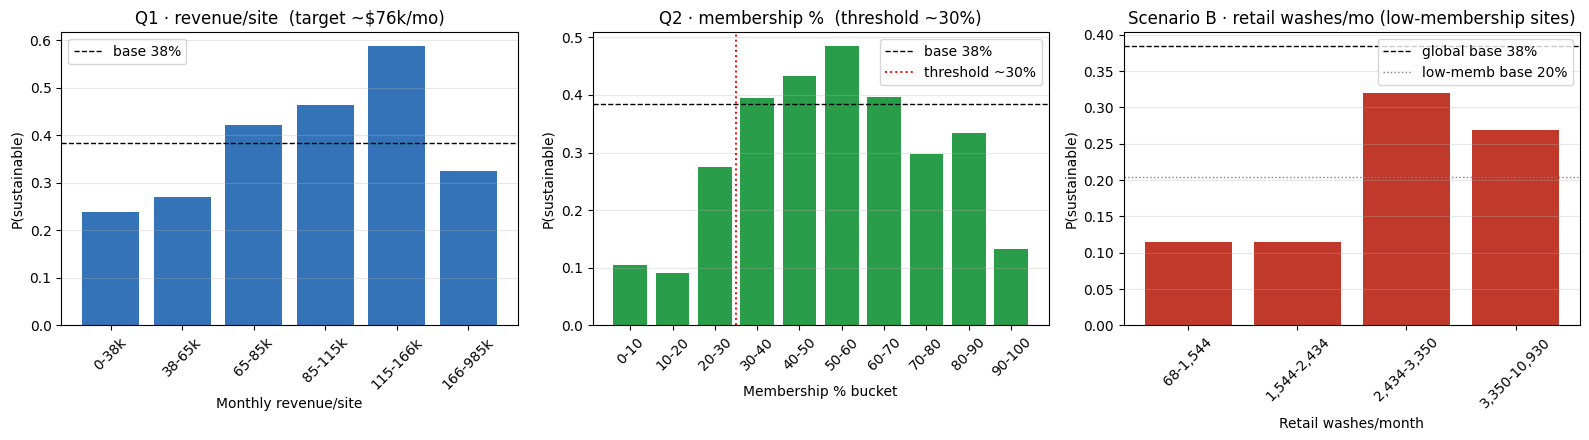

Q1 TARGET REVENUE   ~ $76,207/month per site  (~$0.9M/yr)
Q2 TARGET MEMBERSHIP ~ 30% of revenue
B  RETAIL FALLBACK   ~ 2,809 washes/mo -> lifts low-memb odds to 32% (still short of the 38% membership path)


In [6]:
# ---- Q1: revenue target ----
S['rev_bin'] = pd.qcut(S.avg_rev, 6)
rev_prof = S.groupby('rev_bin', observed=True).agg(p=('sustainable','mean'), mid=('avg_rev','median'))
rev_target = rev_prof[rev_prof.p >= base].mid.min()

# ---- Q2: membership target ----
S['mp_bin'] = pd.cut(S.avg_member_pct, np.arange(0,101,10))
mp_prof = S.groupby('mp_bin', observed=True).agg(p=('sustainable','mean'), n=('sustainable','size'))
mp_target = next((i.left for i, r in mp_prof.iterrows() if r.p >= base and r.n >= 10), None)

# ---- Scenario B: retail fallback among low-membership sites ----
low = S[S.avg_member_pct < mp_target].copy()
low_base = low.sustainable.mean()
low['rv_bin'] = pd.qcut(low.avg_retail_vol, 4)
rv_prof = low.groupby('rv_bin', observed=True).agg(p=('sustainable','mean'), mid=('avg_retail_vol','median'))
reached = rv_prof[rv_prof.p >= base]
if len(reached):
    retail_target, top_p, full = reached.mid.min(), reached.p.max(), True
else:                                          # retail never reaches base -> report its best tier
    best = rv_prof.loc[rv_prof.p.idxmax()]
    retail_target, top_p, full = best.mid, best.p, False

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].bar([f'{i.left/1e3:.0f}-{i.right/1e3:.0f}k' for i in rev_prof.index], rev_prof.p, color='#3573b9')
ax[0].axhline(base, ls='--', color='k', lw=1, label=f'base {base:.0%}')
ax[0].set(title=f'Q1 · revenue/site  (target ~${rev_target/1e3:.0f}k/mo)', xlabel='Monthly revenue/site', ylabel='P(sustainable)')
ax[0].tick_params(axis='x', rotation=45); ax[0].legend(); ax[0].grid(alpha=.3, axis='y')

ax[1].bar([f'{int(i.left)}-{int(i.right)}' for i in mp_prof.index], mp_prof.p, color='#2a9d4a')
ax[1].axhline(base, ls='--', color='k', lw=1, label=f'base {base:.0%}')
ax[1].axvline(mp_target/10 - 0.5, color='red', ls=':', lw=1.4, label=f'threshold ~{mp_target:.0f}%')
ax[1].set(title=f'Q2 · membership %  (threshold ~{mp_target:.0f}%)', xlabel='Membership % bucket', ylabel='P(sustainable)')
ax[1].tick_params(axis='x', rotation=45); ax[1].legend(); ax[1].grid(alpha=.3, axis='y')

ax[2].bar([f'{i.left:,.0f}-{i.right:,.0f}' for i in rv_prof.index], rv_prof.p, color='#c0392b')
ax[2].axhline(base, ls='--', color='k', lw=1, label=f'global base {base:.0%}')
ax[2].axhline(low_base, ls=':', color='gray', lw=1, label=f'low-memb base {low_base:.0%}')
ax[2].set(title='Scenario B · retail washes/mo (low-membership sites)', xlabel='Retail washes/month', ylabel='P(sustainable)')
ax[2].tick_params(axis='x', rotation=45); ax[2].legend(); ax[2].grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

print(f'Q1 TARGET REVENUE   ~ ${rev_target:,.0f}/month per site  (~${rev_target*12/1e6:.1f}M/yr)')
print(f'Q2 TARGET MEMBERSHIP ~ {mp_target:.0f}% of revenue')
print(f'B  RETAIL FALLBACK   ~ {retail_target:,.0f} washes/mo -> lifts low-memb odds to {top_p:.0%}'
      f' ({"fully recovers" if full else "still short of"} the {base:.0%} membership path)')

### 📊 Story — the sustainability rule, and why retail only *softens*

- **Q1 (scale):** below ~\$38k/mo a site is rarely stable (~24%); odds climb past the **38% baseline once it clears ~\$76k/mo (~\$0.9M/yr)** and **peak at ~50–59% in the \$85–166k band**. There is a **minimum scale** below which mix barely matters — you must first be big enough.
- **Q2 (mix):** membership starts beating the baseline around **~30%**, and the **sweet spot is the 40–60% band (43–48% sustainable)**. Below ~30% the odds collapse (9–27%); above ~60% they fade back to ~30–35%. So the target is the **40–60% band**, not a single knife-edge number — and definitely clear of the sub-30% danger zone.
- **Scenario B (retail fallback):** among low-membership sites, retail washes help but **plateau** — odds rise from **~12% to a peak of ~32%** around ~2,800 washes/mo, then **never reach the 38% baseline**. So **heavy retail cushions weak membership but does not replace it** — recurring membership is structurally the stronger lever.

## Scenario B+ · What if a region is *structurally* retail-oriented?

A fair objection: some markets are simply retail-led — low membership isn't a fixable gap, it's the nature of the region. So (1) the heatmap shows **every state's** retail share over time — is it **persistent**? — and (2) the bars show whether being retail-led actually **costs** sustainability.

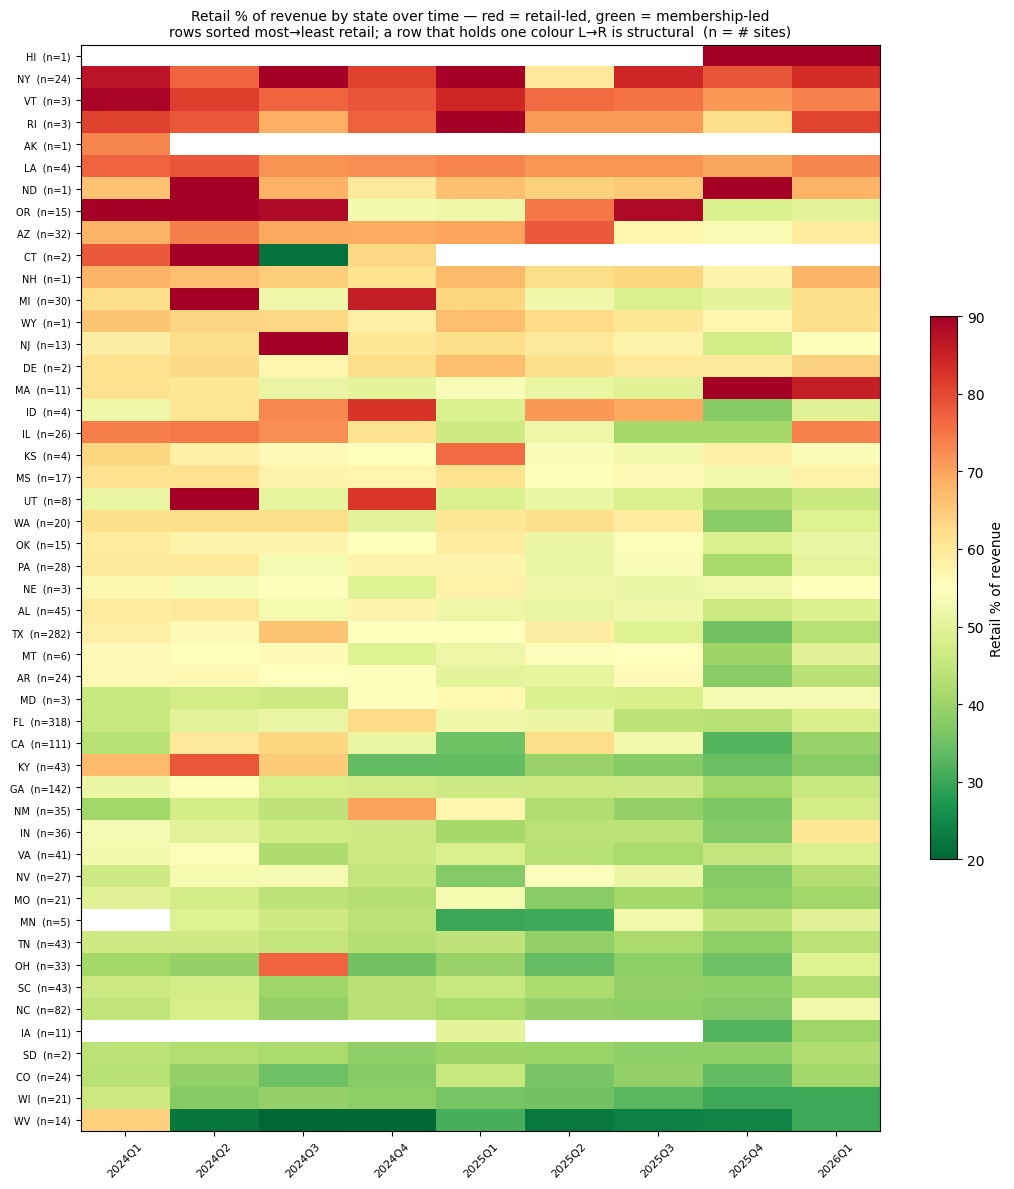

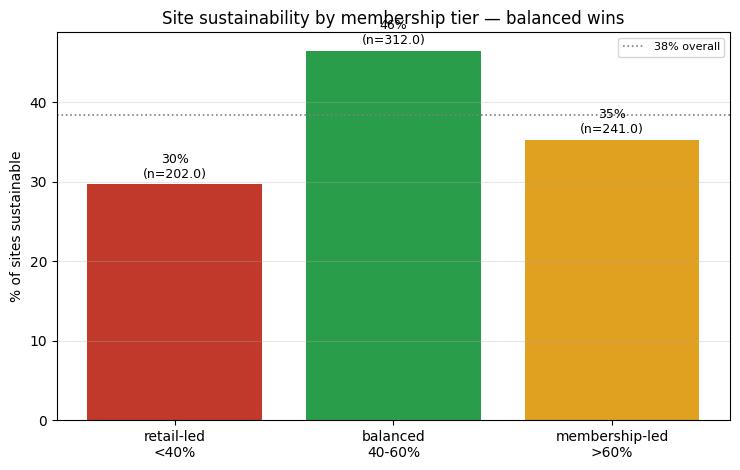

Most retail-led states (>=20 sites): NY 16% memb, MI 27% memb, AZ 37% memb
Retail-dominant sites (membership <40%): 202 = 27% of sites | sustainable 30% vs 38% overall
Sustainability by tier: {'retail-led <40%': '30%', 'balanced 40-60%': '46%', 'membership-led >60%': '35%'}


In [7]:
# state-level membership share & site counts
stw  = site.groupby('state').apply(lambda d: 100*d.membership_sales.sum()/d.total_revenue.sum(), include_groups=False)
scnt = site.groupby('state').apply(lambda d: d.groupby(['client_id','site_id']).ngroups, include_groups=False)
big  = stw[scnt >= 20]
retail_states = big.nsmallest(3).index.tolist()    # most retail-led (e.g. NY, MI, AZ)
memb_states   = big.nlargest(3).index.tolist()     # most membership-led (e.g. WI, CO, SC)

# ===== chart 1: ALL states × quarter — retail % of revenue heatmap =====
site['q'] = site.date.dt.to_period('Q')
hm = (site.groupby(['state','q'])
          .apply(lambda d: 100*d.retail_sales.sum()/d.total_revenue.sum(), include_groups=False)
          .unstack('q'))
hm = hm.loc[hm.mean(axis=1).sort_values(ascending=False).index]   # most retail-led on top
ylab = [f'{s}  (n={scnt[s]})' for s in hm.index]

fig, ax = plt.subplots(figsize=(11, 12))
im = ax.imshow(hm.values, aspect='auto', cmap='RdYlGn_r', vmin=20, vmax=90)
ax.set_yticks(range(len(hm))); ax.set_yticklabels(ylab, fontsize=7)
ax.set_xticks(range(len(hm.columns))); ax.set_xticklabels([str(c) for c in hm.columns], rotation=45, fontsize=8)
fig.colorbar(im, ax=ax, shrink=.5, label='Retail % of revenue')
ax.set_title('Retail % of revenue by state over time — red = retail-led, green = membership-led\n'
             'rows sorted most→least retail; a row that holds one colour L→R is structural  (n = # sites)',
             fontsize=10)
plt.tight_layout(); plt.show()

# ===== chart 2: SITE-level sustainability by membership tier =====
S['tier'] = pd.cut(S.avg_member_pct, [0,40,60,100],
                   labels=['retail-led\n<40%','balanced\n40-60%','membership-led\n>60%'])
tier = S.groupby('tier', observed=True).agg(rate=('sustainable','mean'), n=('sustainable','size'))
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.bar(range(len(tier)), tier.rate*100, color=['#c0392b','#2a9d4a','#e0a020'])
ax.set_xticks(range(len(tier))); ax.set_xticklabels(tier.index.astype(str))
ax.axhline(base*100, color='gray', ls=':', lw=1.2, label=f'{base:.0%} overall')
for i,(_,r) in enumerate(tier.iterrows()):
    ax.text(i, r.rate*100+0.8, f'{r.rate:.0%}\n(n={r.n})', ha='center', fontsize=9)
ax.set(title='Site sustainability by membership tier — balanced wins', ylabel='% of sites sustainable')
ax.legend(fontsize=8); ax.grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

rd = S[S.avg_member_pct < 40]
print(f'Most retail-led states (>=20 sites): ' + ', '.join(f'{s} {big[s]:.0f}% memb' for s in retail_states))
print(f'Retail-dominant sites (membership <40%): {len(rd)} = {len(rd)/len(S):.0%} of sites | '
      f'sustainable {rd.sustainable.mean():.0%} vs {base:.0%} overall')
print('Sustainability by tier:', {str(k).replace(chr(10)," "): f"{v:.0%}" for k,v in tier.rate.items()})

### 📊 Story — retail-led is a real risk, but the cure is *balance*, not max membership

- **Retail dominance is structural, not a phase** (heatmap): each row is a state, colour = its retail share. **Rows hold their colour all the way across** — retail-led states (top, red: NY, OR, AZ, IL…) stay retail-led and membership-led states (bottom, green: WI, CO, NC, SC…) stay membership-led for all 27 months. Big-volume states (TX n=282, FL n=318, GA n=142) sit mid-pack ~50%. *Tiny-n rows (n<5, e.g. HI, VT) are noisy — judge by the high-n rows.* A retail-led market is a fixed condition to plan around, not a temporary dip.
- **The penalty is real but non-linear** (bars): retail-led sites (<40% membership) are sustainable only **30%** vs 38% overall — below average. The **peak is the balanced 40–60% band at ~46%**; pushing membership **past 60% lands back at ~35%** (average — not worse, just no longer an edge). More membership is **not** monotonically better; the goal is to **cross into the balanced zone**, not to maximize membership.
- **Caveat — the signal is per-site, not per-state:** at the whole-state level the membership↔sustainability link washes out (r≈0), because "sustainable" is judged against the national median and big states contain a mix. Read this tier effect at the **site** level.
- **So what — the playbook for retail-led regions:** don't underwrite them to a high membership target they structurally can't reach; aim to **clear ~30% and ideally reach the 40–60% balanced band**, and meanwhile win on **(a) scale** (~\$76k/mo) and **(b) high *and steady* retail volume** (low retail CV). Benchmark membership to the region; judge retail-led markets on **volume + consistency**, not on membership share alone.

### The sustainability rule (per site)

In [8]:
print('='*66)
print('  SUSTAINABILITY RULE FOR A NEW OPERATOR (per site)')
print('='*66)
print( '  On track to be sustainable if a site reaches:')
print(f'    - TOTAL REVENUE   >= ~${rev_target:,.0f} / month   (~${rev_target*12/1e6:.1f}M / yr)')
print(f'    - MEMBERSHIP      in the 40-60% sweet spot  (>= ~{mp_target:.0f}% just to beat average)')
print(f'  If membership stays below ~{mp_target:.0f}%, a large + steady retail base helps:')
if full:
    print(f'    - RETAIL WASHES   >= ~{retail_target:,.0f} washes/mo -> back to AVERAGE odds (~{base:.0%}),')
    print(f'      but the balanced 40-60% membership band still beats it — membership is the stronger lever')
else:
    print(f'    - RETAIL WASHES   ~{retail_target:,.0f}+ washes/mo lifts odds to {top_p:.0%},')
    print(f'      but does NOT fully replace membership ({base:.0%} path) — it softens, not substitutes')
print('='*66)

  SUSTAINABILITY RULE FOR A NEW OPERATOR (per site)
  On track to be sustainable if a site reaches:
    - TOTAL REVENUE   >= ~$76,207 / month   (~$0.9M / yr)
    - MEMBERSHIP      in the 40-60% sweet spot  (>= ~30% just to beat average)
  If membership stays below ~30%, a large + steady retail base helps:
    - RETAIL WASHES   ~2,809+ washes/mo lifts odds to 32%,
      but does NOT fully replace membership (38% path) — it softens, not substitutes


## Step 4c · Same rule at the OPERATOR (client_id) level

Per-site is the comparable unit, but a whole operator's headline number = sites × per-site target. Here is what a **sustainable operator** actually looks like. *(This operator readout is a quick cross-check on monthly revenue; the per-site rule above is the rigorous deseasonalized-quarterly one.)*

In [9]:
# operator-level: total monthly revenue, site count, membership %, stability
og = op.groupby('client_id')
O = og.agg(months=('date','size'), avg_total_rev=('total_revenue','mean'),
           rev_cv=('total_revenue', lambda x: x.std()/x.mean() if x.mean() else np.nan),
           avg_member_pct=('membership_pct','mean'), avg_sites=('n_sites','mean')).reset_index()
def otrend(d):
    y = d.total_revenue.values
    return np.polyfit(np.arange(len(y)),y,1)[0]/y.mean() if len(y)>=6 and y.mean() else np.nan
O['growth'] = og.apply(otrend, include_groups=False).values
O = O[O.months >= 12].copy()
O['sustainable'] = ((O.rev_cv <= O.rev_cv.median()) & (O.growth >= 0)).astype(int)
sus = O[O.sustainable==1]
print(f'operators (>=12 mo): {len(O)} | sustainable: {O.sustainable.mean():.0%}')
print(f'A SUSTAINABLE OPERATOR (median): runs ~{sus.avg_sites.median():.0f} sites, '
      f'${sus.avg_total_rev.median():,.0f}/mo total (~${sus.avg_total_rev.median()*12/1e6:.1f}M/yr), '
      f'{sus.avg_member_pct.median():.0f}% membership')
print(f'vs NON-sustainable (median): ~{O[O.sustainable==0].avg_sites.median():.0f} sites, '
      f'${O[O.sustainable==0].avg_total_rev.median():,.0f}/mo, {O[O.sustainable==0].avg_member_pct.median():.0f}% membership')

operators (>=12 mo): 442 | sustainable: 36%
A SUSTAINABLE OPERATOR (median): runs ~1 sites, $121,762/mo total (~$1.5M/yr), 52% membership
vs NON-sustainable (median): ~1 sites, $83,651/mo, 44% membership


### 📊 Story — operator scale confirms the site rule

Most operators are **single-site** (median = 1 site), so operator ≈ site — which is exactly why the rule agrees at both levels. The median **sustainable** operator runs **~\$122k/mo (~\$1.5M/yr) at ~52% membership**, vs the non-sustainable median of **~\$84k/mo at ~44%** — separated by **scale and mix, not site count**. Multi-site operators are simply a portfolio of sites that each need to clear the per-site bar, so hitting the site target across the fleet makes the operator total follow.

## Step 5 · Export tidy table for Tableau

Long format: **Region / State / Year / Month** + the **Monthly-recurring vs Annual-recurring vs Retail** revenue split, plus per-site membership % for side-by-side operator dashboards.

In [10]:
RAW['stream'] = np.where(RAW.package_plan.str.contains('Annual'), 'Annual recurring', 'Monthly recurring')
mem_stream = (RAW.groupby(['client_id','year','month','stream'])['membership_sales_amount']
                 .sum().reset_index().rename(columns={'membership_sales_amount':'revenue'}))
ret_stream = (site.groupby(['client_id','year','month'])['retail_sales'].sum()
                 .reset_index().rename(columns={'retail_sales':'revenue'}))
ret_stream['stream'] = 'Retail'
streams = pd.concat([mem_stream, ret_stream[['client_id','year','month','stream','revenue']]], ignore_index=True)

tableau = streams.merge(
    op[['client_id','year','month','region','state','membership_pct','total_revenue','n_sites']],
    on=['client_id','year','month'], how='left')
tableau['rev_per_site'] = tableau.total_revenue / tableau.n_sites
tableau['date'] = pd.to_datetime(dict(year=tableau.year, month=tableau.month, day=1))
out = '../data/membership_sustainability_tableau.csv'
tableau.to_csv(out, index=False)
print('wrote', out, tableau.shape)
tableau.head()

wrote ../data/membership_sustainability_tableau.csv (26148, 12)


,client_id,year,month,stream,revenue,region,state,membership_pct,total_revenue,n_sites,rev_per_site,date
0,360 Car Wash,2024,3,Monthly recurring,"8,795.34",South,TX,14.38,"61,155.03",1,"61,155.03",2024-03-01
1,360 Car Wash,2024,4,Monthly recurring,"29,961.10",South,TX,36.26,"82,617.64",1,"82,617.64",2024-04-01
2,360 Car Wash,2024,5,Monthly recurring,"42,705.67",South,TX,47.15,"90,579.49",1,"90,579.49",2024-05-01
3,360 Car Wash,2024,6,Monthly recurring,"51,463.54",South,TX,44.45,"115,786.88",1,"115,786.88",2024-06-01
4,360 Car Wash,2024,7,Monthly recurring,"60,401.75",South,TX,51.84,"116,514.53",1,"116,514.53",2024-07-01


### Takeaways

- **Q1 — target number:** a new site should aim for **~\$76k/month (~\$0.9M/yr)**, ideally the \$85–166k band; below ~\$38k, predictability is rare regardless of mix.
- **Q2 — target membership %:** aim for the **40–60% balanced band** (peak ~46% sustainable) — membership starts beating the baseline ~30% and fades again above ~60%. Stay clear of the sub-30% danger zone. Benchmark to the **state** (penetration ranges low-50s nationally but 29%→71% within a single multi-state brand).
- **Scenario B — retail fallback:** heavy + steady retail washes help but **plateau ~32% and never reach the 38% baseline** — they **cushion** low membership, they don't **replace** it. Membership is the stronger lever.
- `membership_sustainability_tableau.csv` powers the Region/State/Year/Month dashboard with the Monthly / Annual / Retail split for side-by-side operator comparison.